# Exercise 1: GW Parameter Estimation with HMC
This exercise focuses on Bayesian parameter estimation for compact binary coalescences using frequency-domain gravitational-wave data. The goal is to infer the source parameters:

- Chirp mass $M_c$
- Symmetric mass ratio $\eta$, 
- Spins of the two BHs $s_{1,z}$ and  $s_{2,z}$
- Luminosity Distance $d_L$
- Inclination $\iota$
- Phase $\phi_c$
- Coalescence time $t_c$

by comparing a parametric waveform model - specifically, the $\rm IMRPhenomD$ model - to observed detector data.
In particular, I will focus on the observed data of the first gravitational wave event observed, i.e. $\rm GW150914$, for which the same analysis has already been executed, in order to have a direct comparison with my results.

In [ ]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
from matplotlib import pyplot as plt
import corner
from gwpy.timeseries import TimeSeries
import bilby
import jax
import jax.numpy as jnp
from numpyro.infer import MCMC, NUTS
import numpyro
import numpyro.distributions as dist
import ripplegw

### 1. Data Preparation


To retrieve the data and the detector properties, I use the bilby package, optimized for GW data and inference. In particular, I reload the data generated with the data_preparation.ipynb file, since CINECA working nodes do not have Internet acces and my laptop left the battle quite beated...

Once the time series for LIGO Handford and Livingston were retrieved, I used the bilby Interferometer class to perform a Fourier Transform of the data to go to the frequency domain. Additionally, I also computed the noise PSD.

In [ ]:
logger = bilby.core.utils.logger
outdir = "outdir_folder"

label = "GW150914"  
jnp.set_printoptions(precision=3, suppress=False)
jax.config.update("jax_enable_x64", True)

H1 = bilby.gw.detector.get_empty_interferometer("H1")
L1 = bilby.gw.detector.get_empty_interferometer("L1")

In [3]:
geocentric_time = 1126259462.4    # event GPS time at which first GW discovered
post_event = 2                     # time after event
pre_event = 2                      # time before event
duration = pre_event + post_event  # total time range containing event
analysis_begin = geocentric_time - pre_event  # GPS time at which to start analysis

ra = 2.19432
dec = -1.2232
psi = 0.532268

In [4]:
H1_data = TimeSeries.read("H1_data.gwf", channel="H1:Strain")
H1psd = TimeSeries.read("H1_psd.gwf", channel='H1:Strain')

L1_data = TimeSeries.read("L1_data.gwf", channel="L1:Strain")
L1psd = TimeSeries.read("L1_psd.gwf", channel='L1:Strain')

In [5]:
H1.set_strain_data_from_gwpy_timeseries(H1_data)
L1.set_strain_data_from_gwpy_timeseries(L1_data)

In [ ]:
H1_data.plot()
plt.savefig("H1_data")
L1_data.plot()
plt.savefig("L1_data")

In [6]:
# duration typically multiplied by 32 for psd
psd_duration = duration * 32                
psd_begin = analysis_begin - psd_duration

# set interferometers with psd data
psd_alpha = 2 * H1.strain_data.roll_off / duration
H1psd_data = H1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
H1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1psd_data.frequencies.value, psd_array=H1psd_data.value)

psd_alpha = 2 * L1.strain_data.roll_off / duration
L1psd_data = L1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
L1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=L1psd_data.frequencies.value, psd_array=L1psd_data.value)

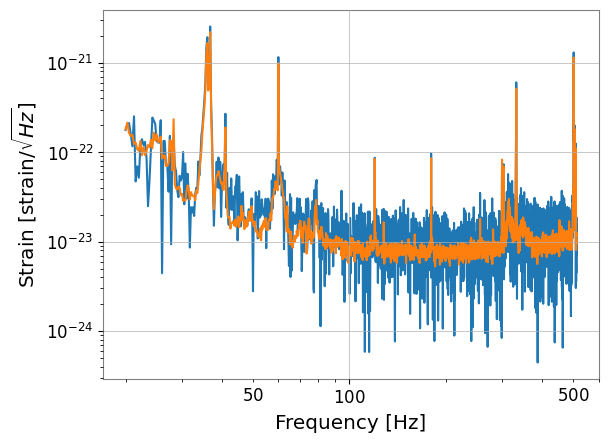

In [7]:
H1.maximum_frequency = 512
idxs = H1.strain_data.frequency_mask
a,b = list(H1.strain_data.frequency_array[idxs]),list(np.abs(H1.strain_data.frequency_domain_strain[idxs]))
c,d = list(H1.power_spectral_density.frequency_array[idxs]),list(H1.power_spectral_density.asd_array[idxs])

L1.maximum_frequency = 512
idxs = L1.strain_data.frequency_mask
L1a,L1b = list(L1.strain_data.frequency_array[idxs]),list(np.abs(L1.strain_data.frequency_domain_strain[idxs]))
L1c,L1d = list(L1.power_spectral_density.frequency_array[idxs]),list(L1.power_spectral_density.asd_array[idxs])
plt.plot(a,b)
plt.plot(c,d)
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Strain [strain/$\sqrt{Hz}$]")
plt.savefig("strainvfreq")

Once in the frequency domain, I prepared the data for the parameter estimation with Numpyro. In particular, I copied all the relevant informations - the frequency arrays, the strains in the frequency domain, the psd of each detector - in JAX arrays. Furthermore, I restricted my data in the relevant frequency range for the $\rm IMRPhenomD$ model, which is given by the $(\rm 20-512 Hz)$ range.

Additionally, from Bilby I also computed the antenna patterns associated with the two detectors during the observation of $\rm GW150914$. Since I assume the position of the source to be known, the values can be computed outside the sampler. If instead the position was part of the parameter estimation, these values would have to be computed with sampled values of RA, dec and $\psi$.

Finally, since I intend to use two detectors to infer the parameters associated with $\rm GW150914$, I also computed the time delay from the geocenter for each detector, to take into account the delay between the two detector observations in my waveform reconstruction.

In [ ]:
f = jnp.array(H1.frequency_array)
fH1 = jnp.array(H1.frequency_array)
fL1 = jnp.array(L1.frequency_array)
maskH1 = (fH1 > 20) & (fH1 < 512)
maskL1 = (fL1 > 20) & (fL1 < 512)
f = f[maskH1]
fH1 = fH1[maskH1]
fL1 = fL1[maskL1]
df = f[1] - f[0]
dfH1 = f[1] - f[0]
dfL1 = f[1] - f[0]

dH1 = jnp.array(H1.strain_data.frequency_domain_strain[maskH1])
psdH1 = jnp.array(H1.power_spectral_density_array[maskH1])
FpH1 = jnp.array(H1.antenna_response(ra, dec, geocentric_time, psi, 'plus'))
FcH1 = jnp.array(H1.antenna_response(ra, dec, geocentric_time, psi, 'cross'))

dL1 = jnp.array(L1.strain_data.frequency_domain_strain[maskL1])
psdL1 = jnp.array(L1.power_spectral_density_array[maskL1])

FpL1 = jnp.array(L1.antenna_response(ra, dec, geocentric_time, psi, 'plus'))
FcL1 = jnp.array(L1.antenna_response(ra, dec, geocentric_time, psi, 'cross'))

tau_H1 = jnp.array(H1.time_delay_from_geocenter(ra, dec, geocentric_time))
tau_L1 = jnp.array(L1.time_delay_from_geocenter(ra, dec, geocentric_time))

0.015669890151329618 0.00857440782365704 1126259460.3999023 1126259460.3999023


For optimization purposes, I compile the $\rm IMRPhenomD$ model outside the sampler. This part is not necessary.

In [ ]:
params_bbh = {
    "M_c": 28.3,   # chirp mass [Msun]
    "eta": 0.247,  # symmetric mass ratio
    "s1_z": 0.0,   # primary spin z-component
    "s2_z": 0.0,   # secondary spin z-component
    "d_L": 440.0,  # luminosity distance [Mpc]
    "phase_c": 0.,
    "iota": 2.0,
}

#jax version for computational efficiency
waveform = ripplegw.IMRPhenomD(f_ref=20.0)
fast_waveform = jax.jit(waveform)

#first call to compile it
pol = fast_waveform(f, params_bbh)

{'c': Array([-2.957e-23+1.389e-23j, -2.555e-23-1.955e-23j,
         4.323e-24-3.139e-23j, ..., -7.611e-28-6.890e-28j,
        -7.559e-28-6.850e-28j, -7.509e-28-6.810e-28j],      dtype=complex128),
 'p': Array([ 1.958e-23+4.168e-23j, -2.755e-23+3.602e-23j,
        -4.425e-23-6.094e-24j, ..., -9.712e-28+1.073e-27j,
        -9.655e-28+1.066e-27j, -9.599e-28+1.058e-27j],      dtype=complex128)}

### 2. Likelihood and Waveform Reconstruction

Once all the data has been prepared, I define the Likelihood and the Waveform model to instruct the HMC sampler.
In particular, for the likelihood I assume the usual GW likelihood, given by the inner product of the residuals between the data and the reconstructed waveform:

\begin{equation*}
    \mathcal{L} = -0.5 <d-h|d-h>
\end{equation*}

where the inner product is given by:


\begin{equation*}
    <a|b> = 4 \rm Re \int{ \frac{\tilde{a}^*(f)\tilde{b}(f)}{S_n(f)}df      }
\end{equation*}

under the assumption of stationary Gaussian noise. 


Waveforms are generated using the RippleGW implementation of the $\rm IMRPhenomD$ model, which provides a fast and differentiable approximation suitable for gradient-based inference. Once the pluss and cross polarization are computed through the $\rm IMRPhenomD$ model, the antenna pattern functions and the time delay with respect to the signal detection are taken into account to compute the final strain of the GW signal for each detector as follows:

\begin{equation*}
    \rm \tilde{h}_d(f) = \bigl(F_{p,d}h_p + F_{c,d}h_c\bigr)\exp\bigl[{-2i\pi f(t_c + \tau_d)}\bigr]
\end{equation*}

where $t_c$ appears outside the plus and cross polarization because the $\rm IMRPhenomD$ model does not include it as a parameter.

In [ ]:
def inner(a, b, Sn, df):
    return 4.0 * jnp.real(jnp.sum(jnp.conj(a) * b)/ Sn) * df

def model(freqsH1, freqsL1, data_f_H1, data_f_L1, psd_H1, psd_L1):
    params = build_params_from_latents()

    f_H1 = freqsH1
    f_L1 = freqsL1
    d_H1 = data_f_H1
    d_L1 = data_f_L1
    Sn_H1 = psd_H1
    Sn_L1 = psd_L1
    dfH1 = f_H1[1] - f_H1[0]
    dfL1 = f_L1[1] - f_L1[0]

    hH1, hL1 = waveform_model(f_H1, f_L1, params)

    rH1 = d_H1 - hH1
    rL1 = d_L1 - hL1
    logL_H1 = - 0.5 * inner(rH1, rH1, Sn_H1, dfH1)
    logL_L1 = - 0.5 * inner(rL1, rL1, Sn_L1, dfL1)
    logL = logL_H1 + logL_L1
    numpyro.factor("log_likelihood", logL)

As for the priors, for each parameters uniform priors are considered.

In [21]:
def build_params_from_latents():
    M_c = numpyro.sample("M_c", dist.Uniform(10., 60.))
    
    eta = numpyro.sample("eta", dist.Uniform(0.1, 0.25))

    s1_z = numpyro.sample("s1_z", dist.Uniform(-0.99, 0.99))

    s2_z = numpyro.sample("s2_z", dist.Uniform(-0.99, 0.99))

    d_L = numpyro.sample("d_L", dist.Uniform(300., 500.))

    t_c = numpyro.sample("t_c", dist.Uniform(geocentric_time-0.1, geocentric_time+0.1))
    
    phase_c = numpyro.sample("phase_c", dist.Uniform(-jnp.pi, jnp.pi))
    
    cos_iota = numpyro.sample("cos_iota", dist.Uniform(-1.,1.))
    iota = jnp.arccos(cos_iota)
    numpyro.deterministic("iota", iota)

    return {
        "M_c": M_c,
        "eta": eta,
        "s1_z": s1_z,
        "s2_z": s2_z,
        "d_L": d_L,
        "t_c": t_c,
        "phase_c": phase_c,
        "iota": iota,
    }

def waveform_model(fH1, fL1, theta):
    wf_params = {
        "M_c": theta["M_c"],
        "eta": theta["eta"],
        "s1_z": theta["s1_z"],
        "s2_z": theta["s2_z"],
        "d_L": theta["d_L"],
        "phase_c": theta["phase_c"],
        "iota": theta["iota"],
    }

    polH1 = fast_waveform(fH1, wf_params)
    polL1 = fast_waveform(fL1, wf_params)

    hpH1, hcH1 = polH1["p"], polH1["c"]
    hpL1, hcL1 = polL1["p"], polL1["c"]

    hdetH1 = FpH1 * hpH1 + FcH1 * hcH1
    hdetL1 = FpL1 * hpL1 + FcL1 * hcL1

    phase_timeH1 = jnp.exp(-2j * jnp.pi * fH1 * (theta["t_c"] + tau_H1))
    phase_timeL1 = jnp.exp(-2j * jnp.pi * fL1 * (theta["t_c"] + tau_L1))

    return hdetH1 * phase_timeH1, hdetL1 * phase_timeL1

Once the likelihood and the reconstructed waveform are defined, the HMC sampler is implemented, with a warmup of 1000 and a number of samples equal to 500.

In [ ]:
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=100, num_samples=100, num_chains=1, progress_bar=True,)

rng_key = jax.random.PRNGKey(1234)
mcmc.run(
    rng_key,
    freqsH1=fH1,
    freqsL1=fL1,
    data_f_H1=dH1,
    data_f_L1=dL1,
    psd_H1=psdH1,
    psd_L1=psdL1,
)

posterior = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/200 [00:14<?, ?it/s]

And the results are visualized through the following corner plot.

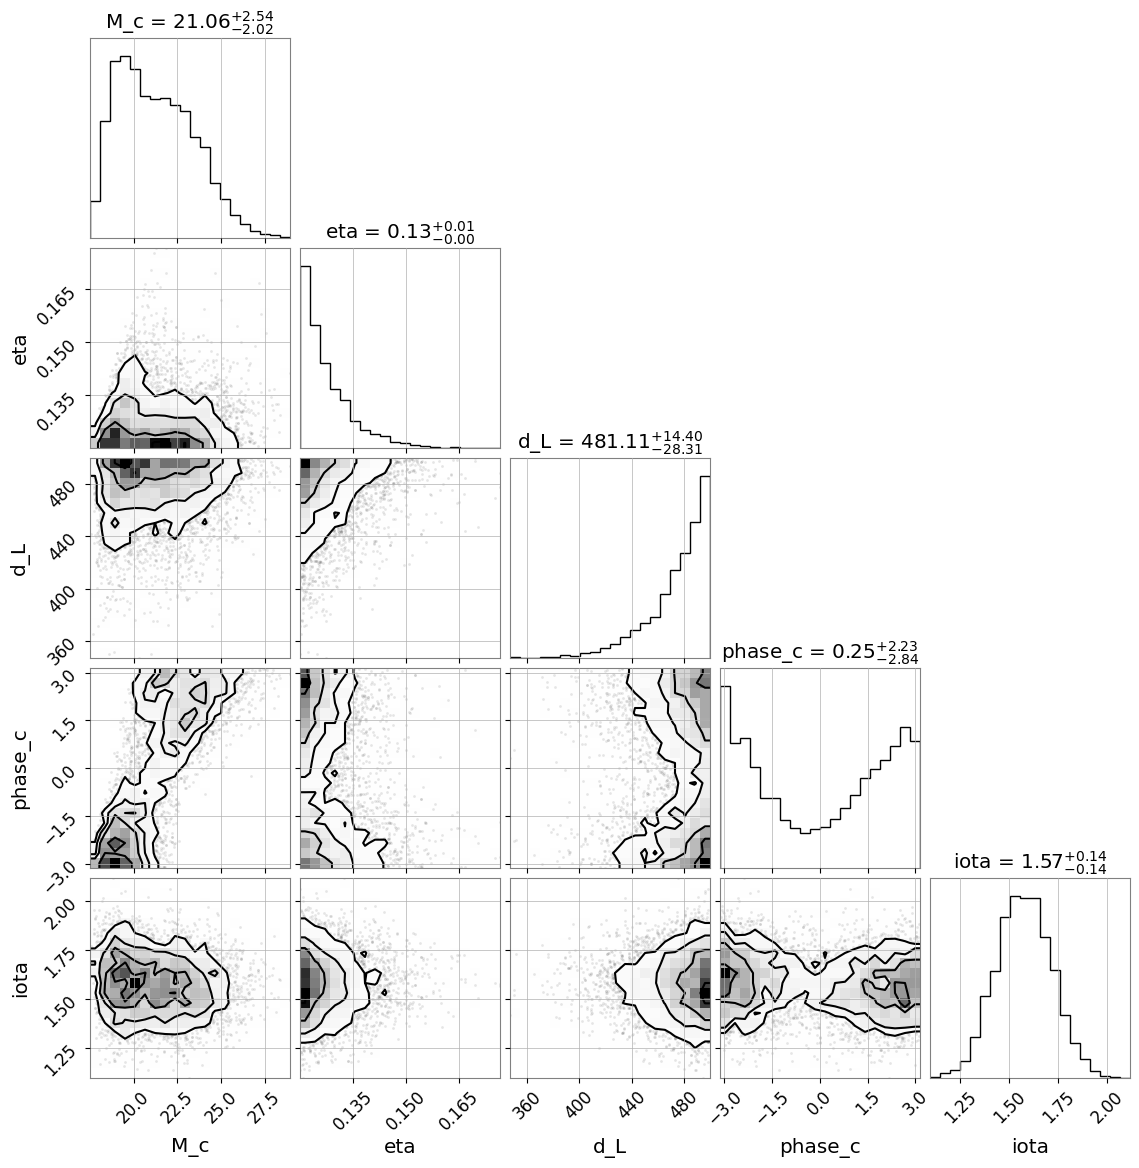

In [ ]:
keys = ["M_c", "eta", "d_L", "phase_c", "iota"]

samples_np = {k: np.array(v) for k, v in posterior.items()}

data = np.vstack([samples_np[k] for k in keys]).T

fig = corner.corner(
    data,
    labels=keys,
    show_titles=True,
    title_fmt=".2f",
)

In [ ]:
params_bbh = {
    "M_c": posterior["M_c"].mean(),   # chirp mass [Msun]
    "eta":  posterior["eta"].mean(),  # symmetric mass ratio
    "s1_z":  0.,   # primary spin z-component
    "s2_z": 0.,   # secondary spin z-component
    "d_L":  posterior["d_L"].mean(),  # luminosity distance [Mpc]
    "phase_c":  posterior["phase_c"].mean(),
    "iota":  posterior["iota"].mean(),
}

print(params_bbh)
waveform = ripplegw.IMRPhenomD(f_ref=50.)
hp, hc = waveform(f, params_bbh)['p'], waveform(f, params_bbh)['c']
hdet = (FpH1*hp + FcH1*hc)*np.exp(-2j * np.pi * f * (tau_H1+ posterior["t_c"].mean()))

{'M_c': Array(21.287, dtype=float64), 'eta': Array(0.128, dtype=float64), 's1_z': 0.0, 's2_z': 0.0, 'd_L': Array(474.702, dtype=float64), 'phase_c': Array(-0.001, dtype=float64), 'iota': Array(1.575, dtype=float64)}


In [ ]:
plt.loglog(f,np.abs(dH1), label = r'$\rm \tilde{h}(f)$')
plt.loglog(c, d, label = 'ASD(f)')
plt.loglog(f, np.abs(hdet), label = 'IMRPhenomD(f)') 
plt.legend()
plt.show()

In [ ]:
def mc_eta_to_m1_m2_gw(mc, eta, G=6.67430e-11, c=299792458.0, M_sun=1.988409870698051e30):
    """
    Convert chirp mass Mc and symmetric mass ratio eta
    to component masses m1, m2, and an estimate of the
    GW frequency at ISCO (f_gw_isco).

    Assumes:
      - mc is in solar masses
      - eta = m1*m2 / (m1+m2)^2
      - returns m1, m2 in solar masses
      - returns f_gw_isco in Hz
    """

    mc = np.asarray(mc, dtype=float)
    eta = np.asarray(eta, dtype=float)

    if np.any(eta <= 0) or np.any(eta > 0.25):
        raise ValueError("eta must satisfy 0 < eta <= 0.25")

    # Total mass: Mc = M * eta^(3/5)
    M = mc / eta**(3.0 / 5.0)

    # Solve x^2 - M x + eta M^2 = 0
    delta = np.sqrt(1.0 - 4.0 * eta)
    m1 = 0.5 * M * (1.0 + delta)
    m2 = 0.5 * M * (1.0 - delta)

    # GW frequency at Schwarzschild ISCO:
    # f_gw_isco = c^3 / (pi * 6^(3/2) * G * M_total)
    M_kg = M * M_sun
    f_gw_isco = c**3 / (np.pi * (6.0**1.5) * G * M_kg)

    return m1, m2, f_gw_isco